In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [30]:
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')

In [31]:
import numpy as np

SEQ_LEN = 12

features = [
'voltage_mean',
'voltage_std',
'voltage_max',
'voltage_min',
'temperature_mean',
'temperature_max',
'capacity',
'capacity_fade',
'cycle_number'
]

target = 'SOH'


def create_sequences(df):

    X = []
    y = []

    for cell in df['cell_id'].unique():

        cell_data = df[df['cell_id'] == cell]

        X_cell = cell_data[features].values
        y_cell = cell_data[target].values

        for i in range(len(cell_data) - SEQ_LEN):

            X.append(X_cell[i:i+SEQ_LEN])
            y.append(y_cell[i+SEQ_LEN])

    return np.array(X), np.array(y)

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [33]:
X_train, y_train = create_sequences(train)

X_test, y_test = create_sequences(test)

In [34]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(288, 13, 9)
(288,)
(127, 13, 9)
(127,)


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense, Input
from tensorflow.keras.optimizers import Adam

model_cnn = Sequential()

model_cnn.add(Input(shape=(SEQ_LEN, len(features))))

model_cnn.add(Conv1D(32, kernel_size=3, activation='relu'))
model_cnn.add(Conv1D(16, kernel_size=3, activation='relu'))

model_cnn.add(GlobalAveragePooling1D())

model_cnn.add(Dense(16, activation='relu'))
model_cnn.add(Dense(1))

model_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

In [36]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 11, 32)              │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 9, 16)               │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ (None, 16)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,737 (10.69 KB)

 Trainable params: 2,737 (10.69 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.5663 - mae: 0.7508 - val_loss: 0.4435 - val_mae: 0.6650
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3495 - mae: 0.5877 - val_loss: 0.2374 - val_mae: 0.4858
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1560 - mae: 0.3891 - val_loss: 0.0702 - val_mae: 0.2621
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0303 - mae: 0.1544 - val_loss: 0.0025 - val_mae: 0.0403
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0078 - mae: 0.0749 - val_loss: 0.0112 - val_mae: 0.0969
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0134 - mae: 0.1028 - val_loss: 0.0048 - val_mae: 0.0580
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0043 - mae: 0.0554 - val_loss: 0.0017 - val_mae: 0.0340
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0028 - mae: 0.0415 - val_loss: 0.0032 - val_mae: 0.0480
Epoch 9/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - mae: 0.0403 -

In [38]:
test_loss_cnn, test_mae_cnn = model_cnn.evaluate(X_test, y_test)
print("CNN Test MAE:", test_mae_cnn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.4210e-04 - mae: 0.0143 
CNN Test MAE: 0.014310470782220364


In [39]:
y_pred = model_cnn.predict(X_test)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/stepWARNING:tensorflow:6 out of the last 13 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002904CE218A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [40]:
y_true = []

for cell in test['cell_id'].unique():
    
    cell_data = test[test['cell_id'] == cell]
    
    y_true.extend(cell_data['SOH'].values[SEQ_LEN:])

y_true = np.array(y_true)

In [41]:
y_pred = y_pred.flatten()


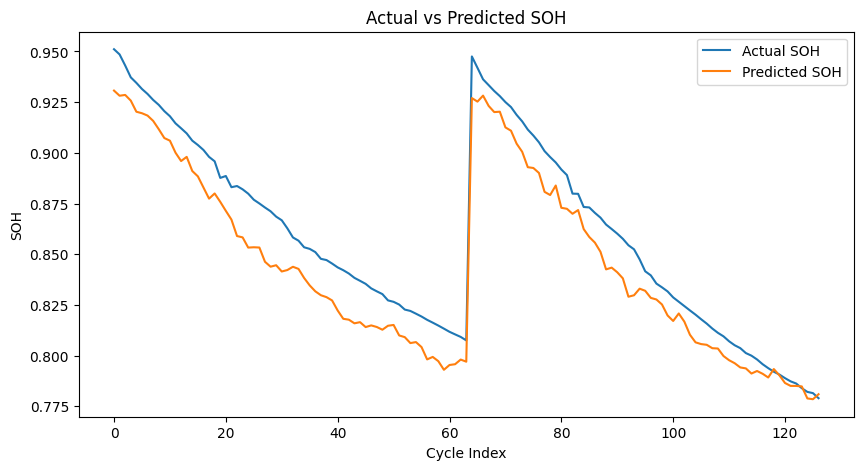

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_true, label="Actual SOH")
plt.plot(y_pred, label="Predicted SOH")

plt.xlabel("Cycle Index")
plt.ylabel("SOH")
plt.title("Actual vs Predicted SOH")

plt.legend()

plt.show()